# AutoMorph on FIVES — segmentation accuracy and feature agreement

Two questions about the benchmark run:

1. **How well does M2 reproduce the expert vessel annotation?** Dice, IoU, sensitivity, specificity.
2. **Do the features AutoMorph reports survive that error?** The same six whole-image features are
   measured from the annotation itself, by the same retipy code, and compared image by image.

The second question is the interesting one. A segmentation can lose a quarter of the annotated
pixels and still report an almost-correct fractal dimension, or be pixel-accurate and report a badly
wrong width. Dice alone does not tell you which features you can trust.

Inputs, all produced by the benchmark:

| Path | Contents |
| --- | --- |
| `benchmark/results/vessel_scores.csv` | Per-image Dice/IoU/sensitivity/specificity |
| `benchmark/results/selection.csv` | The 32 chosen images and their FIVES labels |
| `.benchmark_run/Results/M3/Macular_Features.csv` | Features from the **predicted** segmentation |
| `.benchmark_run/Results/M3/Ground_truth_Macular_Features.csv` | Features from the **annotation** |

Regenerate the last one with `uv run python -m benchmark.ground_truth_features`.

> **`Average_width` is in nominal microns.** FIVES publishes no pixel size, so the benchmark writes a
> placeholder 0.008 mm/pixel. Prediction and truth are scaled by the same per-image figure, so the
> *comparison* holds; the absolute value is not a physical measurement.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd() if (Path.cwd() / "benchmark").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

RESULTS = REPO_ROOT / "benchmark" / "results"
RUN_RESULTS = REPO_ROOT / ".benchmark_run" / "Results"

FEATURES = [
    "Fractal_dimension",
    "Vessel_density",
    "Average_width",
    "Distance_tortuosity",
    "Squared_curvature_tortuosity",
    "Tortuosity_density",
]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})
pd.set_option("display.width", 200)
print(f"repository root: {REPO_ROOT}")

repository root: /Users/staskh/Sandbox/AutoMorph


## Load and join

In [2]:
def strip_suffix(series):
    return series.str.replace(".png", "", regex=False)


scores = pd.read_csv(RESULTS / "vessel_scores.csv")
selection = pd.read_csv(RESULTS / "selection.csv")

predicted = pd.read_csv(RUN_RESULTS / "M3" / "Macular_Features.csv")[["Name"] + FEATURES]
truth = pd.read_csv(RUN_RESULTS / "M3" / "Ground_truth_Macular_Features.csv")[["Name"] + FEATURES]
predicted["key"] = strip_suffix(predicted["Name"])
truth["key"] = strip_suffix(truth["Name"])

# A -1 in any feature is retipy's failed-measurement marker, not a value.
for frame in (predicted, truth):
    frame[FEATURES] = frame[FEATURES].mask(frame[FEATURES] == -1)

paired = (
    predicted.drop(columns="Name")
    .merge(truth.drop(columns="Name"), on="key", suffixes=("_pred", "_gt"))
    .merge(scores[["key", "disease", "status", "dice", "iou", "sensitivity", "specificity"]], on="key")
)

print(f"{len(selection)} images selected, {(scores['status'] == 'ok').sum()} segmented, {len(paired)} paired")
print()
print(scores["status"].value_counts().to_string())

32 images selected, 26 segmented, 26 paired

status
ok                 26
no_segmentation     6


## 1. Where images dropped out

M1 is a gate, not a report: `merge_quality_assessment.py` sorts images into `Good_quality/` or
`Bad_quality/`, and M2 only reads the former. A rejected image yields no segmentation and no
features at all — so the drop-out belongs in the results, not in a footnote.

In [3]:
gate = selection[["key", "disease"]].merge(scores[["key", "status"]], on="key")
gate["reached_segmentation"] = gate["status"] == "ok"

summary = gate.groupby("disease").agg(
    selected=("key", "size"),
    segmented=("reached_segmentation", "sum"),
)
summary["rejected"] = summary["selected"] - summary["segmented"]
summary["rejected_pct"] = (100 * summary["rejected"] / summary["selected"]).round(1)
display(summary)

print("rejected images:", ", ".join(sorted(gate.loc[~gate["reached_segmentation"], "key"])))

,selected,segmented,rejected,rejected_pct
disease,,,,
amd,8,8,0,0.0
dr,8,7,1,12.5
glaucoma,8,8,0,0.0
normal,8,3,5,62.5


rejected images: test_151_N, test_158_N, test_161_N, test_162_N, test_167_N, test_56_D


## 2. Segmentation accuracy

Vessels occupy roughly 2% of the field of view, so **specificity and accuracy sit near 1 for any
prediction** and carry almost no information. Read Dice and IoU; read sensitivity to see which way
the errors fall.

In [4]:
ok = paired[paired["status"] == "ok"]
metrics = ["dice", "iou", "sensitivity", "specificity"]

display(ok[metrics].describe().round(4))
display(ok.groupby("disease")[metrics].agg(["mean", "std"]).round(4))

,dice,iou,sensitivity,specificity
count,26.0000,26.0000,26.0000,26.0000
mean,0.8321,0.7155,0.7474,0.9947
std,0.0534,0.0706,0.0792,0.0022
min,0.6196,0.4489,0.4636,0.9909
25%,0.8191,0.6936,0.7174,0.9929
50%,0.8447,0.7314,0.7642,0.9948
75%,0.8632,0.7594,0.7973,0.9965
max,0.8792,0.7845,0.8281,0.9987


dice             iou         sensitivity         specificity        
            mean     std    mean     std        mean     std        mean     std
disease                                                                         
amd       0.8530  0.0255  0.7445  0.0382      0.7761  0.0483      0.9948  0.0016
dr        0.7886  0.0840  0.6573  0.1064      0.6810  0.1155      0.9962  0.0023
glaucoma  0.8420  0.0234  0.7277  0.0350      0.7628  0.0419      0.9941  0.0021
normal    0.8511  0.0307  0.7415  0.0458      0.7844  0.0489      0.9923  0.0006

/var/folders/fr/9n81007x72d8q41sk2r0hsfm0000gn/T/ipykernel_46375/2248729462.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([ok.loc[ok["disease"] == d, "dice"] for d in order], labels=order)


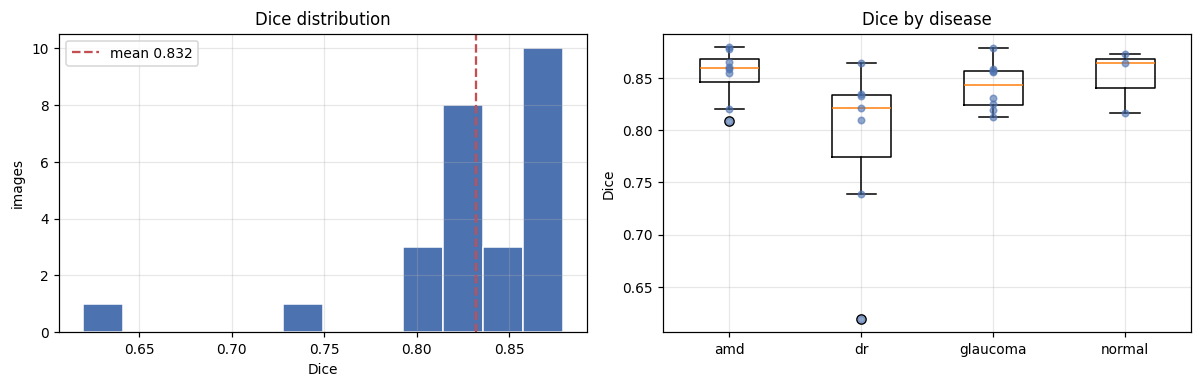

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(ok["dice"], bins=12, color="#4C72B0", edgecolor="white")
axes[0].axvline(ok["dice"].mean(), color="#C44E52", ls="--", label=f"mean {ok['dice'].mean():.3f}")
axes[0].set(xlabel="Dice", ylabel="images", title="Dice distribution")
axes[0].legend()

order = sorted(ok["disease"].unique())
axes[1].boxplot([ok.loc[ok["disease"] == d, "dice"] for d in order], labels=order)
for index, disease in enumerate(order, start=1):
    values = ok.loc[ok["disease"] == disease, "dice"]
    axes[1].scatter(np.full(len(values), index), values, alpha=0.6, s=18, color="#4C72B0", zorder=3)
axes[1].set(ylabel="Dice", title="Dice by disease")

fig.tight_layout()

correlation of Dice with sensitivity: 0.987
correlation of Dice with specificity: -0.589


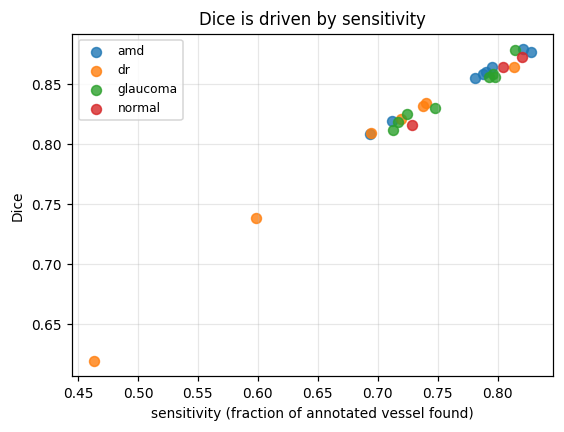

In [6]:
# Sensitivity against specificity: where does the model trade one for the other?
fig, ax = plt.subplots(figsize=(5.2, 4))
for disease in order:
    subset = ok[ok["disease"] == disease]
    ax.scatter(subset["sensitivity"], subset["dice"], label=disease, s=42, alpha=0.8)
ax.set(xlabel="sensitivity (fraction of annotated vessel found)", ylabel="Dice",
       title="Dice is driven by sensitivity")
ax.legend(fontsize=8)
fig.tight_layout()

print("correlation of Dice with sensitivity:", round(ok["dice"].corr(ok["sensitivity"]), 3))
print("correlation of Dice with specificity:", round(ok["dice"].corr(ok["specificity"]), 3))

## 3. Feature agreement

For each feature, predicted against ground truth:

- **bias** — mean signed difference, and the same as a percentage of the truth's mean. A systematic
  offset. Correctable by calibration if it is stable.
- **MAPE** — mean absolute percentage error. Per-image reliability.
- **Pearson r** — linear agreement. **Spearman** — rank agreement, which is what matters if the
  feature is used to order or stratify patients rather than to report an absolute number.
- **Bland–Altman limits** — mean difference ± 1.96 SD, the interval containing ~95% of differences.

A feature can have a large bias and still be useful (rank-preserving), or a small bias and be
useless (uncorrelated). Both columns are needed.

In [7]:
def agreement(frame, features=FEATURES):
    rows = []
    for feature in features:
        pair = frame[[f"{feature}_pred", f"{feature}_gt"]].dropna()
        prediction, reference = pair[f"{feature}_pred"], pair[f"{feature}_gt"]
        difference = prediction - reference
        rows.append(
            {
                "feature": feature,
                "n": len(pair),
                "gt_mean": reference.mean(),
                "pred_mean": prediction.mean(),
                "bias": difference.mean(),
                "bias_%": 100 * difference.mean() / reference.mean(),
                "MAPE_%": 100 * (difference.abs() / reference.abs()).mean(),
                "pearson_r": prediction.corr(reference),
                "spearman_r": prediction.corr(reference, method="spearman"),
                "BA_low": difference.mean() - 1.96 * difference.std(),
                "BA_high": difference.mean() + 1.96 * difference.std(),
            }
        )
    return pd.DataFrame(rows).set_index("feature")


agreement_table = agreement(ok)
display(agreement_table.round(3))

,n,gt_mean,pred_mean,bias,bias_%,MAPE_%,pearson_r,spearman_r,BA_low,BA_high
feature,,,,,,,,,,
Fractal_dimension,26,1.473,1.445,-0.028,-1.918,1.938,0.938,0.914,-0.070,0.013
Vessel_density,26,0.083,0.067,-0.017,-20.008,20.846,0.939,0.908,-0.027,-0.007
Average_width,26,114.106,100.069,-14.037,-12.302,12.313,0.789,0.838,-25.637,-2.437
Distance_tortuosity,26,3.467,3.833,0.366,10.561,25.764,0.465,0.642,-2.143,2.875
Squared_curvature_tortuosity,26,22.922,29.509,6.587,28.737,89.325,0.097,0.173,-39.757,52.931
Tortuosity_density,26,0.691,0.687,-0.003,-0.498,3.246,0.802,0.791,-0.056,0.049


In [8]:
# Is the linear agreement statistically distinguishable from zero at n=26?
for feature in FEATURES:
    pair = ok[[f"{feature}_pred", f"{feature}_gt"]].dropna()
    r, p = stats.pearsonr(pair[f"{feature}_pred"], pair[f"{feature}_gt"])
    rho, p_rho = stats.spearmanr(pair[f"{feature}_pred"], pair[f"{feature}_gt"])
    verdict = "" if p < 0.05 else "   <-- not significant"
    print(f"{feature:32s} r={r:6.3f} (p={p:.2g})   rho={rho:6.3f} (p={p_rho:.2g}){verdict}")

Fractal_dimension                r= 0.938 (p=1.5e-12)   rho= 0.914 (p=7.1e-11)
Vessel_density                   r= 0.939 (p=1.2e-12)   rho= 0.908 (p=1.4e-10)
Average_width                    r= 0.789 (p=1.7e-06)   rho= 0.838 (p=9.2e-08)
Distance_tortuosity              r= 0.465 (p=0.017)   rho= 0.642 (p=0.0004)
Squared_curvature_tortuosity     r= 0.097 (p=0.64)   rho= 0.173 (p=0.4)   <-- not significant
Tortuosity_density               r= 0.802 (p=8.6e-07)   rho= 0.791 (p=1.5e-06)


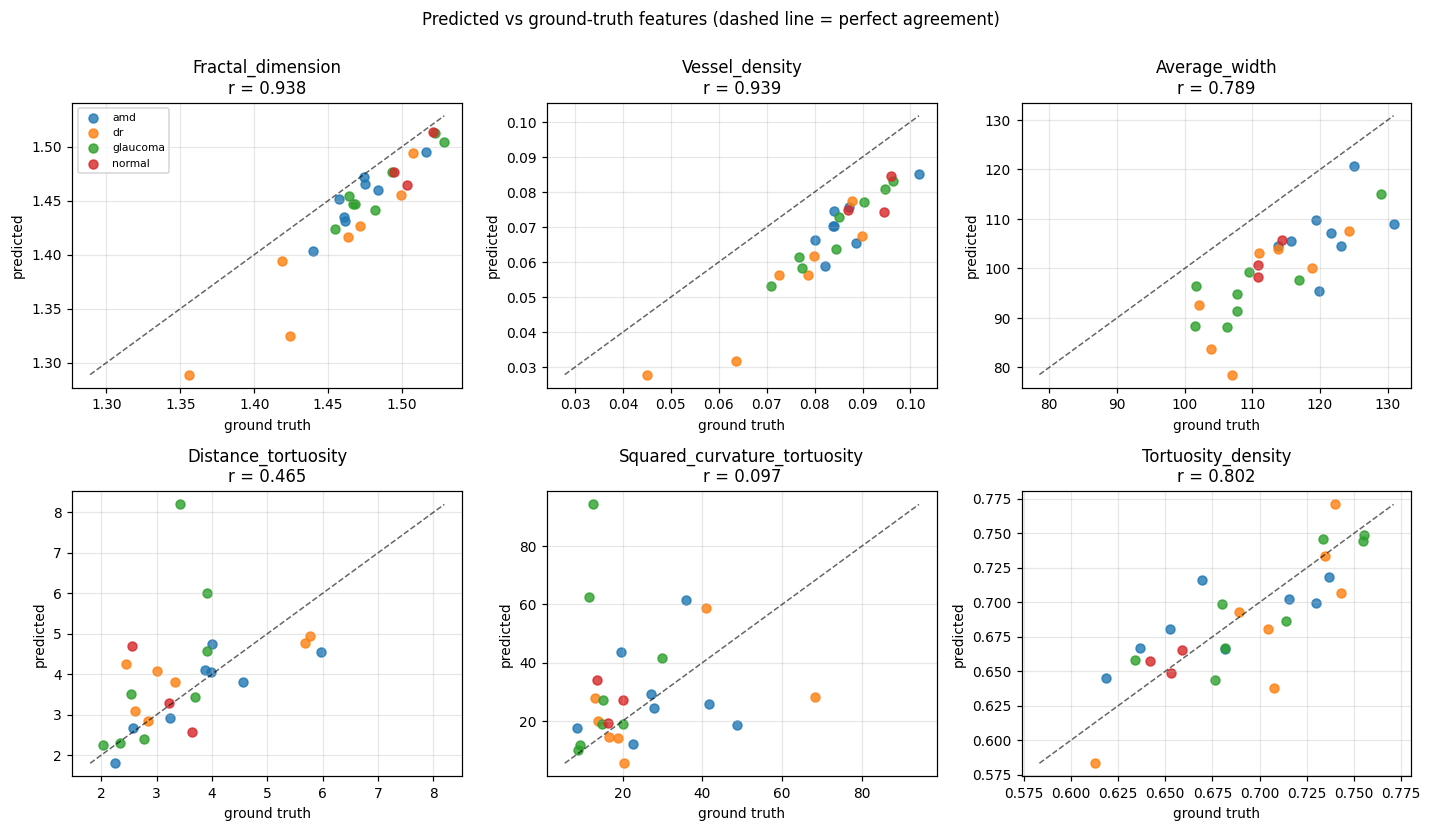

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "disease"]].dropna()
    for disease in order:
        subset = pair[pair["disease"] == disease]
        ax.scatter(subset[f"{feature}_gt"], subset[f"{feature}_pred"], label=disease, s=34, alpha=0.8)

    combined = pd.concat([pair[f"{feature}_gt"], pair[f"{feature}_pred"]])
    limits = [combined.min(), combined.max()]
    ax.plot(limits, limits, "k--", lw=1, alpha=0.6)
    r = pair[f"{feature}_pred"].corr(pair[f"{feature}_gt"])
    ax.set(xlabel="ground truth", ylabel="predicted", title=f"{feature}\nr = {r:.3f}")

axes[0, 0].legend(fontsize=7)
fig.suptitle("Predicted vs ground-truth features (dashed line = perfect agreement)", y=1.0)
fig.tight_layout()

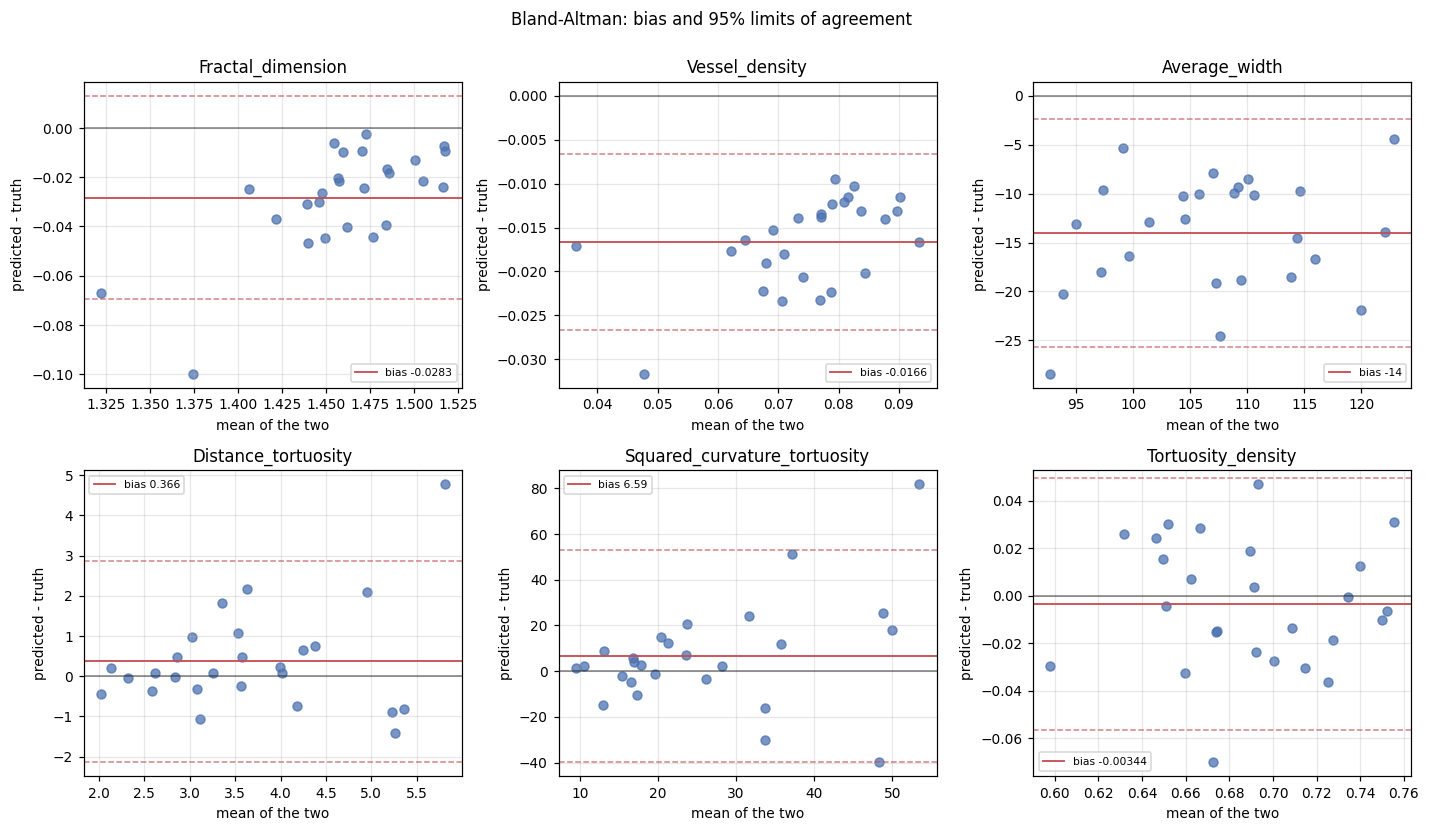

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt"]].dropna()
    mean = (pair[f"{feature}_pred"] + pair[f"{feature}_gt"]) / 2
    difference = pair[f"{feature}_pred"] - pair[f"{feature}_gt"]

    ax.scatter(mean, difference, s=34, alpha=0.75, color="#4C72B0")
    ax.axhline(0, color="k", lw=1, alpha=0.5)
    ax.axhline(difference.mean(), color="#C44E52", ls="-", lw=1.2, label=f"bias {difference.mean():.3g}")
    for limit in (difference.mean() - 1.96 * difference.std(), difference.mean() + 1.96 * difference.std()):
        ax.axhline(limit, color="#C44E52", ls="--", lw=1, alpha=0.7)
    ax.set(xlabel="mean of the two", ylabel="predicted - truth", title=feature)
    ax.legend(fontsize=7)

fig.suptitle("Bland-Altman: bias and 95% limits of agreement", y=1.0)
fig.tight_layout()

## 4. Does Dice predict feature error?

If it does, Dice is a usable proxy for feature trustworthiness on unlabelled data — which is the
only situation that matters in practice, since you will not have annotations. If it does not, a
good Dice is no guarantee that the reported morphometry is right.

In [11]:
rows = []
for feature in FEATURES:
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "dice", "sensitivity"]].dropna()
    relative_error = (pair[f"{feature}_pred"] - pair[f"{feature}_gt"]).abs() / pair[f"{feature}_gt"].abs()
    rows.append(
        {
            "feature": feature,
            "corr(dice, |rel err|)": pair["dice"].corr(relative_error),
            "corr(sens, |rel err|)": pair["sensitivity"].corr(relative_error),
            "median_|rel err|_%": 100 * relative_error.median(),
        }
    )

display(pd.DataFrame(rows).set_index("feature").round(3))

,"corr(dice, |rel err|)","corr(sens, |rel err|)",median_|rel err|_%
feature,,,
Fractal_dimension,-0.939,-0.945,1.601
Vessel_density,-0.960,-0.992,18.646
Average_width,-0.731,-0.752,11.631
Distance_tortuosity,-0.062,-0.089,16.027
Squared_curvature_tortuosity,-0.050,-0.098,43.318
Tortuosity_density,-0.188,-0.199,3.056


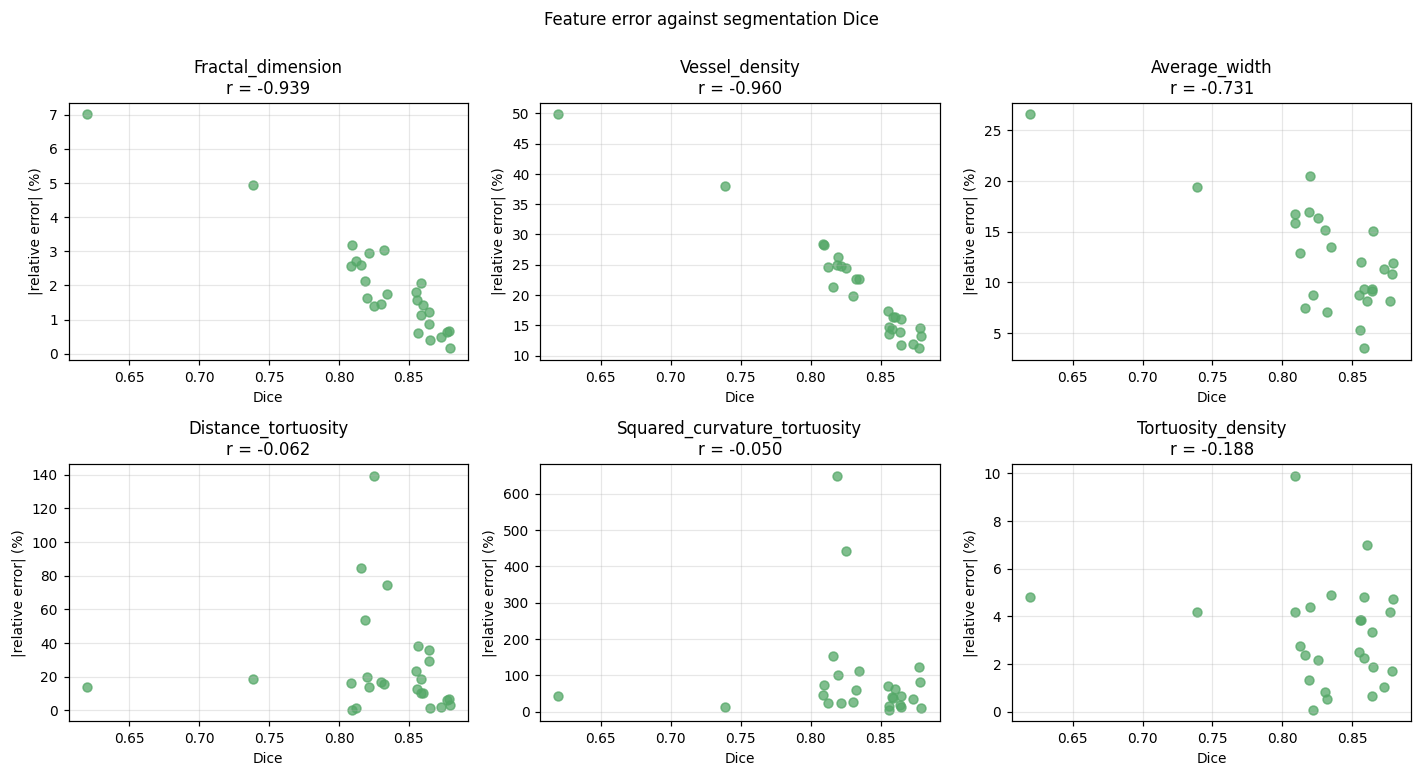

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, feature in zip(axes.ravel(), FEATURES):
    pair = ok[[f"{feature}_pred", f"{feature}_gt", "dice"]].dropna()
    relative_error = 100 * (pair[f"{feature}_pred"] - pair[f"{feature}_gt"]).abs() / pair[f"{feature}_gt"].abs()
    ax.scatter(pair["dice"], relative_error, s=34, alpha=0.75, color="#55A868")
    ax.set(xlabel="Dice", ylabel="|relative error| (%)",
           title=f"{feature}\nr = {pair['dice'].corr(relative_error):.3f}")

fig.suptitle("Feature error against segmentation Dice", y=1.0)
fig.tight_layout()

## 5. Per-disease agreement

Small groups — read as indicative, not conclusive.

In [13]:
for disease in order:
    subset = ok[ok["disease"] == disease]
    print(f"\n=== {disease}  (n={len(subset)}, mean Dice {subset['dice'].mean():.3f}) ===")
    display(agreement(subset)[["bias_%", "MAPE_%", "pearson_r", "spearman_r"]].round(3))


=== amd  (n=8, mean Dice 0.853) ===


,bias_%,MAPE_%,pearson_r,spearman_r
feature,,,,
Fractal_dimension,-1.332,1.335,0.905,0.810
Vessel_density,-18.145,18.182,0.763,0.571
Average_width,-11.660,11.599,0.395,0.357
Distance_tortuosity,-5.936,12.466,0.826,0.786
Squared_curvature_tortuosity,0.263,57.959,0.133,0.190
Tortuosity_density,0.987,3.897,0.765,0.714



=== dr  (n=7, mean Dice 0.789) ===


,bias_%,MAPE_%,pearson_r,spearman_r
feature,,,,
Fractal_dimension,-3.357,3.393,0.941,0.964
Vessel_density,-26.710,28.285,0.934,0.964
Average_width,-14.286,14.360,0.747,0.750
Distance_tortuosity,8.215,24.783,0.756,0.571
Squared_curvature_tortuosity,-12.003,52.743,0.461,0.250
Tortuosity_density,-2.548,3.968,0.859,0.750



=== glaucoma  (n=8, mean Dice 0.842) ===


,bias_%,MAPE_%,pearson_r,spearman_r
feature,,,,
Fractal_dimension,-1.452,1.455,0.948,0.762
Vessel_density,-18.518,18.907,0.974,0.976
Average_width,-12.397,12.363,0.875,0.786
Distance_tortuosity,32.745,35.040,0.645,0.738
Squared_curvature_tortuosity,133.653,160.579,0.045,0.405
Tortuosity_density,-0.633,2.669,0.878,0.881



=== normal  (n=3, mean Dice 0.851) ===


,bias_%,MAPE_%,pearson_r,spearman_r
feature,,,,
Fractal_dimension,-1.435,1.438,0.835,0.5
Vessel_density,-15.789,15.760,0.595,0.5
Average_width,-9.289,9.309,0.948,1.0
Distance_tortuosity,12.349,38.776,-0.998,-1.0
Squared_curvature_tortuosity,60.759,68.316,-0.411,-0.5
Tortuosity_density,0.924,1.363,0.342,0.5


## 6. Verdict per feature

The table below is generated from the numbers above, not hand-written, so it cannot drift out of
sync with the data. The thresholds are judgement calls and stated explicitly in the code.

In [14]:
def verdict(row):
    if row["pearson_r"] < 0.4 or row["MAPE_%"] > 50:
        return "unreliable - do not use per-image"
    if abs(row["bias_%"]) > 10:
        return "rank-usable, biased - calibrate before absolute use"
    if row["MAPE_%"] < 5:
        return "reliable"
    return "usable with care"


verdicts = agreement_table[["bias_%", "MAPE_%", "pearson_r", "spearman_r"]].copy()
verdicts["verdict"] = agreement_table.apply(verdict, axis=1)
display(verdicts.round(3).sort_values("pearson_r", ascending=False))

,bias_%,MAPE_%,pearson_r,spearman_r,verdict
feature,,,,,
Vessel_density,-20.008,20.846,0.939,0.908,"rank-usable, biased - calibrate before absolut..."
Fractal_dimension,-1.918,1.938,0.938,0.914,reliable
Tortuosity_density,-0.498,3.246,0.802,0.791,reliable
Average_width,-12.302,12.313,0.789,0.838,"rank-usable, biased - calibrate before absolut..."
Distance_tortuosity,10.561,25.764,0.465,0.642,"rank-usable, biased - calibrate before absolut..."
Squared_curvature_tortuosity,28.737,89.325,0.097,0.173,unreliable - do not use per-image


In [15]:
# Save the tables next to the rest of the benchmark output.
agreement_table.round(6).to_csv(RESULTS / "feature_agreement.csv")
verdicts.round(6).to_csv(RESULTS / "feature_verdicts.csv")
print(f"wrote feature_agreement.csv and feature_verdicts.csv to {RESULTS}")

wrote feature_agreement.csv and feature_verdicts.csv to /Users/staskh/Sandbox/AutoMorph/benchmark/results
